In [12]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
# to avoid error:
# huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
# To disable this warning, you can either:
# 	- Avoid using `tokenizers` before the fork if possible
# 	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)

In [1]:
%cd /root/TalkTuner-chatbot-llm-dashboard
import sys
if "src" not in sys.path:
    sys.path.append("src")

/root/TalkTuner-chatbot-llm-dashboard


/opt/conda/envs/talktuner-gpu/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
!nvidia-smi

Wed Sep  2 13:08:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L40S                    On  |   00000000:34:00.0 Off |                    0 |
| N/A   57C    P8             38W /  350W |       0MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os
from torch.utils.data import Dataset
from torch.utils.data.dataloader import DataLoader
import torch.nn.functional as F
from losses import edl_mse_loss

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
from tqdm.auto import tqdm

from dataset import TextDataset 
from losses import edl_mse_loss

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

from probes import ProbeClassification, ProbeClassificationMixScaler
from train_test_utils import train, test 
import torch.nn as nn

import time

tic, toc = (time.time, time.time)

In [4]:
tokenizer = AutoTokenizer.from_pretrained("NousResearch/Llama-2-13b-chat-hf")
model = AutoModelForCausalLM.from_pretrained("NousResearch/Llama-2-13b-chat-hf")
model.half().cuda();
model.eval();

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [5]:
!nvidia-smi

Wed Sep  2 13:09:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L40S                    On  |   00000000:34:00.0 Off |                    0 |
| N/A   57C    P0             94W /  350W |   25385MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
from src.probes import ProbeClassification, ProbeClassificationMixScaler
    
class TrainerConfig:
    # optimization parameters
    learning_rate = 1e-3
    betas = (0.9, 0.95)
    weight_decay = 0.1 # only applied on matmul weights
    # learning rate decay params: linear warmup followed by cosine decay to 10% of original
    # checkpoint settings

    def __init__(self, **kwargs):
        for k,v in kwargs.items():
            setattr(self, k, v)

## Linear Probing on All Attributes

In [7]:
import os
from torch.utils.data import Dataset
from torch.utils.data.dataloader import DataLoader
import torch.nn.functional as F

import torch
from tqdm.auto import tqdm
from src.dataset import split_conversation, llama_v2_prompt, TextDataset

### Reading Probes

In [8]:
# scripts/unzip_dataset.sh

In [9]:
# note: datasets are missing
# there's no openai_age_3 or openai_socioeconomic_3 at all (only _1 and _2 exist for those)
# commented below lines of code to avoid errors when running the script

  0%|          | 0/4000 [00:00<?, ?it/s]

Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)


Corrupted file at data/dataset/openai_age_2/conversation_650_age_adolescent.txt
Corrupted file at data/dataset/openai_age_2/conversation_735_age_older adult.txt
Corrupted file at data/dataset/openai_age_2/conversation_740_age_child.txt


  0%|          | 0/41 [00:00<?, ?it/s]

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 0----------------------------------------


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 


Train set: Average loss: 0.6011 (2.497 sec) Accuracy: 0.250



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Test set: Average loss: 0.6011,  Accuracy: 0.250



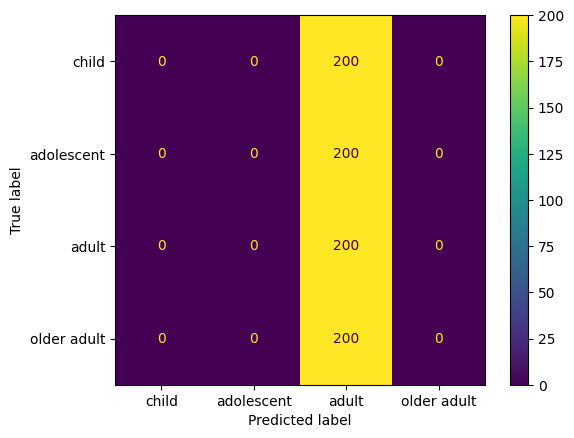

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 1----------------------------------------


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 


Train set: Average loss: 0.5731 (2.469 sec) Accuracy: 0.416



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Test set: Average loss: 0.5732,  Accuracy: 0.405



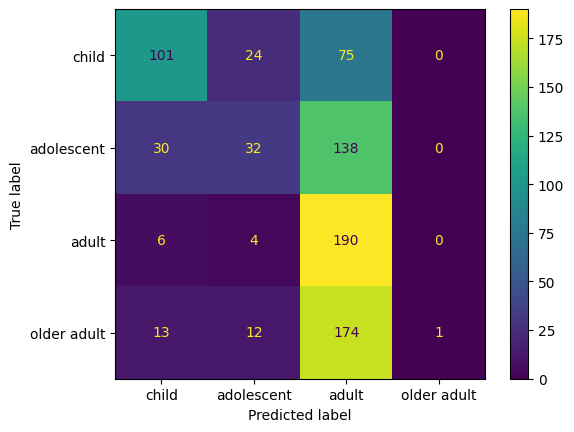

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 2----------------------------------------


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 


Train set: Average loss: 0.5651 (2.468 sec) Accuracy: 0.468



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Test set: Average loss: 0.5651,  Accuracy: 0.458



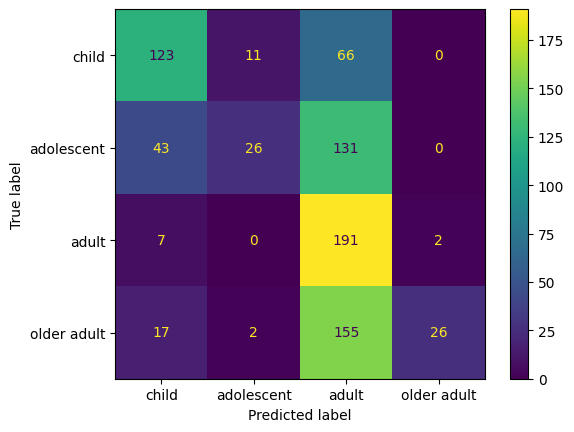

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 3----------------------------------------


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

KeyboardInterrupt: 

In [10]:
from probes import LinearProbeClassification, LinearProbeClassificationMixScaler
import sklearn.model_selection
import pickle
import random

jump_socioeco = True

new_prompt_format=True
residual_stream=True
uncertainty = False
logistic = True
augmented = False
remove_last_ai_response = True
include_inst = True
one_hot = True

label_to_id_age = {"child": 0,
                   "adolescent": 1,
                   "adult": 2,
                   "older adult": 3,
                  }

label_to_id_gender = {"male": 0,
                      "female": 1,
                     }

label_to_id_socioeconomic = {"low": 0,
                             "middle": 1,
                             "high": 2}

label_to_id_neweducation = {"someschool": 0,
                            "highschool": 1,
                            "collegemore": 2}

prompt_translator = {"_age_": "age",
                     "_gender_": "gender",
                     "_socioeco_": "socioeconomic status",
                     "_education_": "education level",}

openai_dataset = {"_age_": "data/dataset/openai_age_1/",
                  "_gender_": "data/dataset/openai_gender_1/",
                  "_education_": "data/dataset/openai_education_three_classes_1/",
                  "_socioeco_": "data/dataset/openai_socioeconomic_1/",}

accuracy_dict = {}

import os
os.makedirs("probe_checkpoints/reading_probe", exist_ok=True)

directories = ["data/dataset/llama_age_1/", "data/dataset/llama_gender_1/",
               "data/dataset/llama_socioeconomic_1/", "data/dataset/openai_education_three_classes_1/"]

label_idfs = ["_age_", "_gender_", "_socioeco_", "_education_"]

label_to_ids = [label_to_id_age, label_to_id_gender,
                label_to_id_socioeconomic, label_to_id_neweducation]

for directory, label_idf, label_to_id in zip(directories, label_idfs, label_to_ids):
    # additional_dataset=[directory[:-1] + "_additional/"]
    if label_idf == "_education_":
        additional_dataset=[]
    else:
        additional_dataset=[directory[:-2] + "2/", openai_dataset[label_idf]]
    if label_idf == "_gender_":
        additional_dataset += ["data/dataset/openai_gender_2/", "data/dataset/openai_gender_3/", 
                               "data/dataset/openai_gender_4",]
    if label_idf == "_education_":
        additional_dataset += ["data/dataset/openai_education_three_classes_2", "data/dataset/openai_education_three_classes_3/"]
    if label_idf == "_socioeco_":
        additional_dataset += ["data/dataset/openai_socioeconomic_2/"]
        # additional_dataset += ["data/dataset/openai_socioeconomic_3/"]  # not downloaded yet, uncomment once available
    if label_idf == "_age_":
        additional_dataset += ["data/dataset/openai_age_2/"]
        # additional_dataset += ["data/dataset/openai_age_3/"]  # not downloaded yet, uncomment once available
        
    dataset = TextDataset(directory, tokenizer, model, label_idf=label_idf, label_to_id=label_to_id,
                          convert_to_llama2_format=True, additional_datas=additional_dataset, 
                          new_format=new_prompt_format,
                          residual_stream=residual_stream, if_augmented=augmented, 
                          remove_last_ai_response=remove_last_ai_response, include_inst=include_inst, k=1,
                          one_hot=False, last_tok_pos=-1)
    dict_name = label_idf.strip("_")

    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_idx, val_idx = sklearn.model_selection.train_test_split(list(range(len(dataset))), 
                                                                  test_size=test_size,
                                                                  train_size=train_size,
                                                                  random_state=12345,
                                                                  shuffle=True,
                                                                  stratify=dataset.labels,
                                                                 )

    train_dataset = Subset(dataset, train_idx)
    test_dataset = Subset(dataset, val_idx)

    sampler = None
    train_loader = DataLoader(train_dataset, shuffle=True, sampler=sampler, pin_memory=True, batch_size=200, num_workers=1)
    test_loader = DataLoader(test_dataset, shuffle=False, pin_memory=True, batch_size=400, num_workers=1)

    if uncertainty:
        loss_func = edl_mse_loss
    else:
        loss_func = nn.BCELoss()
    torch_device = "cuda"

    accuracy_dict[dict_name] = []
    accuracy_dict[dict_name + "_final"] = []
    accuracy_dict[dict_name + "_train"] = []
        
    accs = []
    final_accs = []
    train_accs = []
    for i in tqdm(range(0, 41)):
        trainer_config = TrainerConfig()
        probe = LinearProbeClassification(probe_class=len(label_to_id.keys()), device="cuda", input_dim=5120,
                                            logistic=logistic)
        optimizer, scheduler = probe.configure_optimizers(trainer_config)
        best_acc = 0
        max_epoch = 50
        verbosity = False
        layer_num = i
        print("-" * 40 + f"Layer {layer_num}" + "-" * 40)
        for epoch in range(1, max_epoch + 1):
            if epoch == max_epoch:
                verbosity = True
            # Get the train results from training of each epoch
            if uncertainty:
                train_results = train(probe, torch_device, train_loader, optimizer, 
                                        epoch, loss_func=loss_func, verbose_interval=None,
                                        verbose=verbosity, layer_num=layer_num, 
                                        return_raw_outputs=True, epoch_num=epoch, num_classes=len(label_to_id.keys()))
                test_results = test(probe, torch_device, test_loader, loss_func=loss_func, 
                                    return_raw_outputs=True, verbose=verbosity, layer_num=layer_num,
                                    scheduler=scheduler, epoch_num=epoch, num_classes=len(label_to_id.keys()))
            else:
                train_results = train(probe, torch_device, train_loader, optimizer, 
                                        epoch, loss_func=loss_func, verbose_interval=None,
                                        verbose=verbosity, layer_num=layer_num,
                                        return_raw_outputs=True,
                                        one_hot=one_hot, num_classes=len(label_to_id.keys()))
                test_results = test(probe, torch_device, test_loader, loss_func=loss_func, 
                                    return_raw_outputs=True, verbose=verbosity, layer_num=layer_num,
                                    scheduler=scheduler,
                                    one_hot=one_hot, num_classes=len(label_to_id.keys()))

            if test_results[1] > best_acc:
                best_acc = test_results[1]
                torch.save(probe.state_dict(), f"probe_checkpoints/reading_probe/{dict_name}_probe_at_layer_{layer_num}.pth")
        torch.save(probe.state_dict(), f"probe_checkpoints/reading_probe/{dict_name}_probe_at_layer_{layer_num}_final.pth")
        
        accs.append(best_acc)
        final_accs.append(test_results[1])
        train_accs.append(train_results[1])
        cm = confusion_matrix(test_results[3], test_results[2])
        cm_display = ConfusionMatrixDisplay(cm, display_labels=label_to_id.keys()).plot()
        plt.show()

        accuracy_dict[dict_name].append(accs)
        accuracy_dict[dict_name + "_final"].append(final_accs)
        accuracy_dict[dict_name + "_train"].append(train_accs)
        
        with open("probe_checkpoints/reading_probe_experiment.pkl", "wb") as outfile:
            pickle.dump(accuracy_dict, outfile)
    del dataset, train_dataset, test_dataset, train_loader, test_loader
    torch.cuda.empty_cache()

# L4
# 9mins for age_probe_at_layer_0.pth
# ...
# 16mins for age_probe_at_layer_2.pth

training run will show similar confusion matrices with acc & loss scores
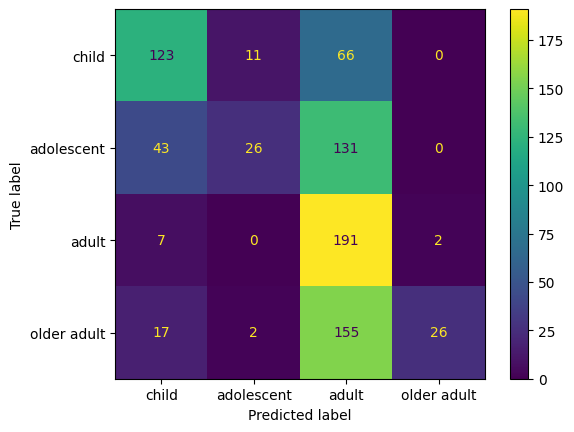

### Control Probe

  0%|          | 0/4000 [00:00<?, ?it/s]

Corrupted file at data/dataset/openai_age_2/conversation_650_age_adolescent.txt
Corrupted file at data/dataset/openai_age_2/conversation_735_age_older adult.txt
Corrupted file at data/dataset/openai_age_2/conversation_740_age_child.txt


  0%|          | 0/41 [00:00<?, ?it/s]

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 0----------------------------------------

Train set: Average loss: 0.5947 (2.608 sec) Accuracy: 0.246

Test set: Average loss: 0.5947,  Accuracy: 0.250



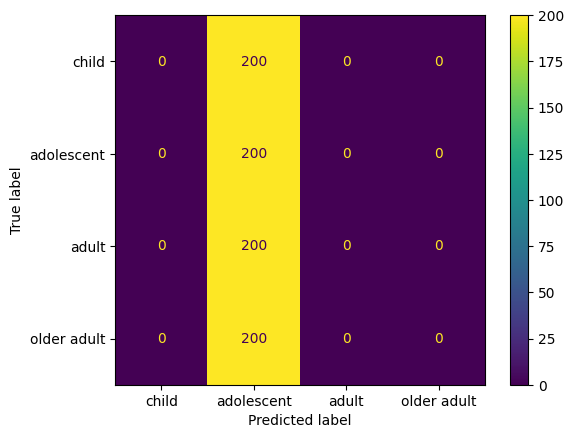

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 1----------------------------------------

Train set: Average loss: 0.5706 (2.632 sec) Accuracy: 0.440

Test set: Average loss: 0.5707,  Accuracy: 0.444



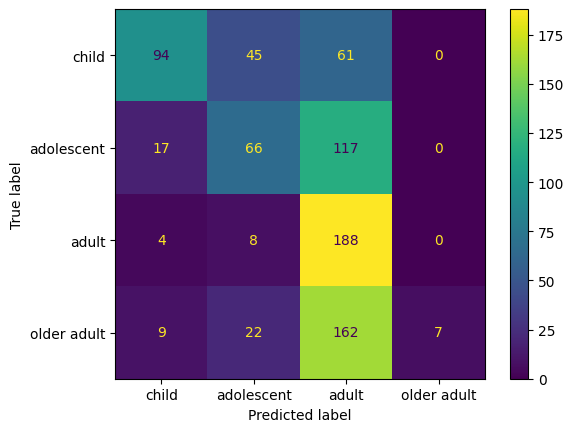

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 2----------------------------------------

Train set: Average loss: 0.5611 (2.635 sec) Accuracy: 0.489

Test set: Average loss: 0.5612,  Accuracy: 0.465



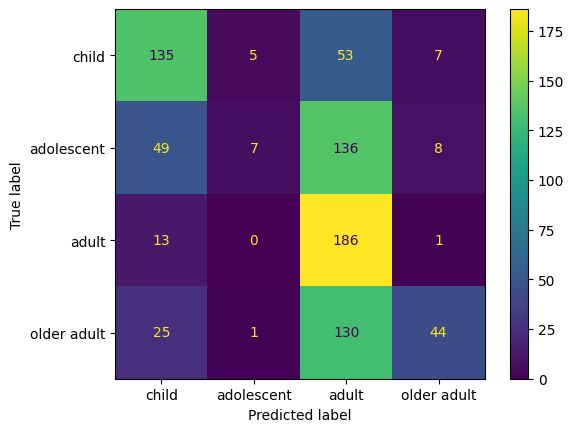

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 3----------------------------------------


KeyboardInterrupt: 

In [13]:
from probes import LinearProbeClassification, LinearProbeClassificationMixScaler
import sklearn.model_selection
import pickle
import random

jump_socioeco = True

new_prompt_format=True
residual_stream=True
uncertainty = False
logistic = True
augmented = False
remove_last_ai_response = True
include_inst = True
one_hot = True

label_to_id_age = {"child": 0,
                   "adolescent": 1,
                   "adult": 2,
                   "older adult": 3,
                  }

label_to_id_gender = {"male": 0,
                      "female": 1,
                     }

label_to_id_socioeconomic = {"low": 0,
                             "middle": 1,
                             "high": 2}

label_to_id_neweducation = {"someschool": 0,
                            "highschool": 1,
                            "collegemore": 2}

prompt_translator = {"_age_": "age",
                     "_gender_": "gender",
                     "_socioeco_": "socioeconomic status",
                     "_education_": "education level",}

openai_dataset = {"_age_": "data/dataset/openai_age_1/",
                  "_gender_": "data/dataset/openai_gender_1/",
                  "_education_": "data/dataset/openai_education_three_classes_1/",
                  "_socioeco_": "data/dataset/openai_socioeconomic_1/",}

accuracy_dict = {}

import os
os.makedirs("probe_checkpoints/controlling_probe", exist_ok=True)

directories = ["data/dataset/llama_age_1/", "data/dataset/llama_gender_1/",
               "data/dataset/llama_socioeconomic_1/", "data/dataset/openai_education_three_classes_1/"]

label_idfs = ["_age_", "_gender_", "_socioeco_", "_education_"]

label_to_ids = [label_to_id_age, label_to_id_gender,
                label_to_id_socioeconomic, label_to_id_neweducation]

for directory, label_idf, label_to_id in zip(directories, label_idfs, label_to_ids):
    # additional_dataset=[directory[:-1] + "_additional/"]
    if label_idf == "_education_":
        additional_dataset=[]
    else:
        additional_dataset=[directory[:-2] + "2/", openai_dataset[label_idf]]
    if label_idf == "_gender_":
        additional_dataset += ["data/dataset/openai_gender_2/", "data/dataset/openai_gender_3/", 
                               "data/dataset/openai_gender_4",]
    if label_idf == "_education_":
        additional_dataset += ["data/dataset/openai_education_three_classes_2", "data/dataset/openai_education_three_classes_3/"]
    if label_idf == "_socioeco_":
        additional_dataset += ["data/dataset/openai_socioeconomic_2/"]
        # additional_dataset += ["data/dataset/openai_socioeconomic_3/"]  # not downloaded yet, uncomment once available
    if label_idf == "_age_":
        additional_dataset += ["data/dataset/openai_age_2/"]
        # additional_dataset += ["data/dataset/openai_age_3/"]  # not downloaded yet, uncomment once available
        
    dataset = TextDataset(directory, tokenizer, model, label_idf=label_idf, label_to_id=label_to_id,
                          convert_to_llama2_format=True, additional_datas=additional_dataset, 
                          new_format=new_prompt_format, control_probe=True,
                          residual_stream=residual_stream, if_augmented=augmented, 
                          remove_last_ai_response=remove_last_ai_response, include_inst=include_inst, k=1,
                          one_hot=False, last_tok_pos=-1)
    dict_name = label_idf.strip("_")

    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_idx, val_idx = sklearn.model_selection.train_test_split(list(range(len(dataset))), 
                                                                  test_size=test_size,
                                                                  train_size=train_size,
                                                                  random_state=12345,
                                                                  shuffle=True,
                                                                  stratify=dataset.labels,
                                                                 )

    train_dataset = Subset(dataset, train_idx)
    test_dataset = Subset(dataset, val_idx)

    sampler = None
    train_loader = DataLoader(train_dataset, shuffle=True, sampler=sampler, pin_memory=True, batch_size=200, num_workers=1)
    test_loader = DataLoader(test_dataset, shuffle=False, pin_memory=True, batch_size=400, num_workers=1)

    if uncertainty:
        loss_func = edl_mse_loss
    else:
        loss_func = nn.BCELoss()
    torch_device = "cuda"

    accuracy_dict[dict_name] = []
    accuracy_dict[dict_name + "_final"] = []
    accuracy_dict[dict_name + "_train"] = []
        
    accs = []
    final_accs = []
    train_accs = []
    for i in tqdm(range(0, 41)):
        trainer_config = TrainerConfig()
        probe = LinearProbeClassification(probe_class=len(label_to_id.keys()), device="cuda", input_dim=5120,
                                            logistic=logistic)
        optimizer, scheduler = probe.configure_optimizers(trainer_config)
        best_acc = 0
        max_epoch = 50
        verbosity = False
        layer_num = i
        print("-" * 40 + f"Layer {layer_num}" + "-" * 40)
        for epoch in range(1, max_epoch + 1):
            if epoch == max_epoch:
                verbosity = True
            # Get the train results from training of each epoch
            if uncertainty:
                train_results = train(probe, torch_device, train_loader, optimizer, 
                                        epoch, loss_func=loss_func, verbose_interval=None,
                                        verbose=verbosity, layer_num=layer_num, 
                                        return_raw_outputs=True, epoch_num=epoch, num_classes=len(label_to_id.keys()))
                test_results = test(probe, torch_device, test_loader, loss_func=loss_func, 
                                    return_raw_outputs=True, verbose=verbosity, layer_num=layer_num,
                                    scheduler=scheduler, epoch_num=epoch, num_classes=len(label_to_id.keys()))
            else:
                train_results = train(probe, torch_device, train_loader, optimizer, 
                                        epoch, loss_func=loss_func, verbose_interval=None,
                                        verbose=verbosity, layer_num=layer_num,
                                        return_raw_outputs=True,
                                        one_hot=one_hot, num_classes=len(label_to_id.keys()))
                test_results = test(probe, torch_device, test_loader, loss_func=loss_func, 
                                    return_raw_outputs=True, verbose=verbosity, layer_num=layer_num,
                                    scheduler=scheduler,
                                    one_hot=one_hot, num_classes=len(label_to_id.keys()))

            if test_results[1] > best_acc:
                best_acc = test_results[1]
                torch.save(probe.state_dict(), f"probe_checkpoints/controlling_probe/{dict_name}_probe_at_layer_{layer_num}.pth")
        torch.save(probe.state_dict(), f"probe_checkpoints/controlling_probe/{dict_name}_probe_at_layer_{layer_num}_final.pth")
        
        accs.append(best_acc)
        final_accs.append(test_results[1])
        train_accs.append(train_results[1])
        cm = confusion_matrix(test_results[3], test_results[2])
        cm_display = ConfusionMatrixDisplay(cm, display_labels=label_to_id.keys()).plot()
        plt.show()

        accuracy_dict[dict_name].append(accs)
        accuracy_dict[dict_name + "_final"].append(final_accs)
        accuracy_dict[dict_name + "_train"].append(train_accs)
        
        with open("probe_checkpoints/controlling_probe_experiment.pkl", "wb") as outfile:
            pickle.dump(accuracy_dict, outfile)
    del dataset, train_dataset, test_dataset, train_loader, test_loader
    torch.cuda.empty_cache()

we will see confusion matrix like below with test set loss and acc.

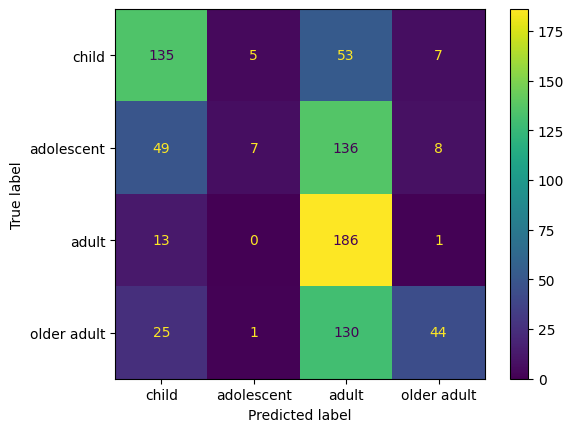